In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df2 = pd.read_csv("S:\\DATA SET\\Stock Prices Data Set.csv")

print(df2.columns)

# convert correct date column
df2['date'] = pd.to_datetime(df2['date'])



Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


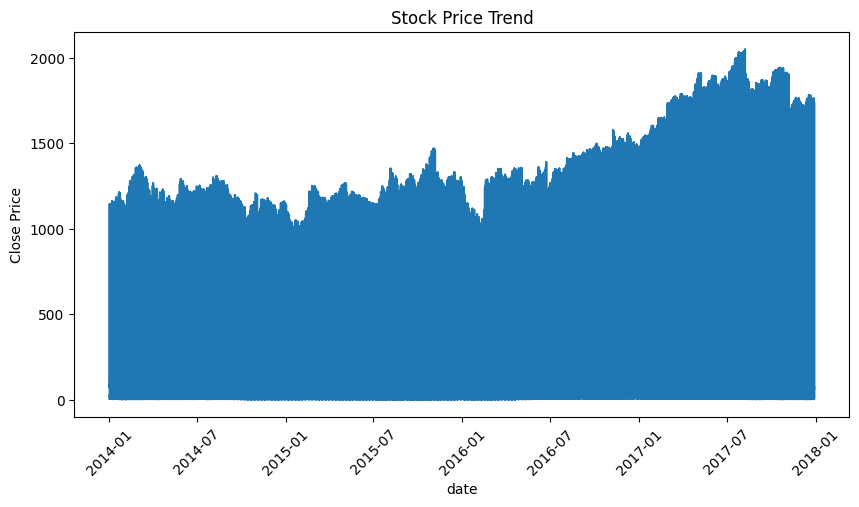

In [2]:
import matplotlib.pyplot as plt

# convert date
df2['date'] = pd.to_datetime(df2['date'])

# sort by date
df2 = df2.sort_values('date')

plt.figure(figsize=(10,5))

plt.plot(df2['date'], df2['close'])

plt.title("Stock Price Trend")
plt.xlabel("date")
plt.ylabel("Close Price")

plt.xticks(rotation=45)
plt.show()

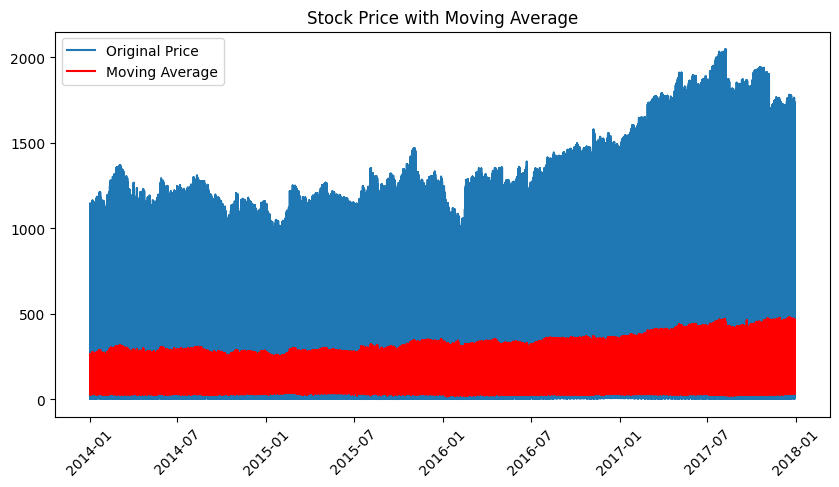

In [3]:
# moving average (5 days)
df2['MA_5'] = df2['close'].rolling(window=5).mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df2['date'], df2['close'], label="Original Price")
plt.plot(df2['date'], df2['MA_5'], label="Moving Average", color='red')

plt.legend()
plt.title("Stock Price with Moving Average")

plt.xticks(rotation=45)
plt.show()


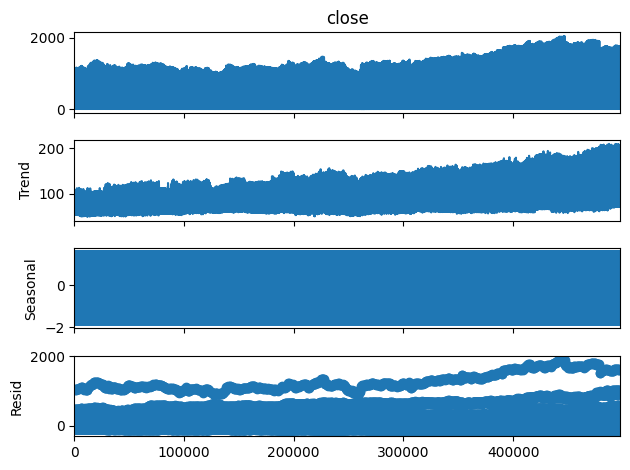

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposition
decomposition = seasonal_decompose(df2['close'], model='additive', period=30)

# Plot
decomposition.plot()
plt.show()

In [6]:
# Regression Analysis

In [7]:
import pandas as pd

# load space-separated dataset
df1 = pd.read_csv("S:\\DATA SET\\house Prediction Data Set.csv", sep='\s+', header=None)
print(df1.head())
print(df1.shape)

        0     1     2   3      4      5     6       7   8      9     10  \
0  0.00632  18.0  2.31   0  0.538  6.575  65.2  4.0900   1  296.0  15.3   
1  0.02731   0.0  7.07   0  0.469  6.421  78.9  4.9671   2  242.0  17.8   
2  0.02729   0.0  7.07   0  0.469  7.185  61.1  4.9671   2  242.0  17.8   
3  0.03237   0.0  2.18   0  0.458  6.998  45.8  6.0622   3  222.0  18.7   
4  0.06905   0.0  2.18   0  0.458  7.147  54.2  6.0622   3  222.0  18.7   

       11    12    13  
0  396.90  4.98  24.0  
1  396.90  9.14  21.6  
2  392.83  4.03  34.7  
3  394.63  2.94  33.4  
4  396.90  5.33  36.2  
(506, 14)


In [8]:
df1.columns = [
    "CRIM","ZN","INDUS","CHAS","NOX","RM","AGE",
    "DIS","RAD","TAX","PTRATIO","B","LSTAT","PRICE"
]

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df1.drop("PRICE", axis=1)
y = df1["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("R2 Score:", model.score(X_test, y_test))

R2 Score: 0.7798082707102452


Columns: Index(['_0.00632__18.00___2.310__0__0.5380__6.5750__65.20__4.0900___1__296.0__15.30_396.90___4.98__24.00'], dtype='object')
Columns used for clustering: Index(['_0.00632__18.00___2.310__0__0.5380__6.5750__65.20__4.0900___1__296.0__15.30_396.90___4.98__24.00'], dtype='object')


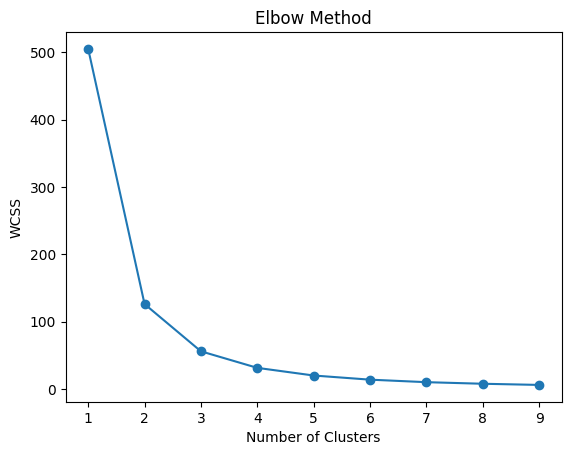


Cluster Count:
cluster
1    170
2    168
0    167
Name: count, dtype: int64


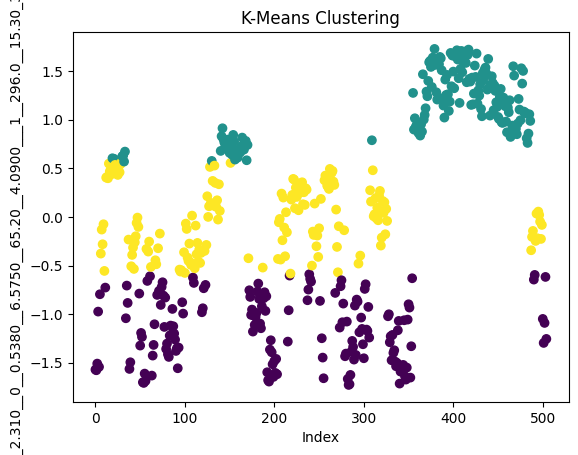


Conclusion:
The dataset is grouped into clusters based on similar house features like area, bedrooms, etc.


In [10]:
# ==============================
# K-MEANS CLUSTERING (FIXED)
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("S:\\DATA SET\\house Prediction Data Set.csv")

# Clean column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

print("Columns:", df.columns)

# ==============================
# ENCODE CATEGORICAL DATA
# ==============================
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# ==============================
# CONVERT TO NUMERIC + HANDLE MISSING
# ==============================
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.fillna(df.mean())

# ==============================
# FEATURE SELECTION
# ==============================
X = df.select_dtypes(include=np.number)

print("Columns used for clustering:", X.columns)

# ==============================
# SCALING
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# ELBOW METHOD
# ==============================
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ==============================
# FINAL MODEL
# ==============================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster Count:")
print(df['cluster'].value_counts())

# ==============================
# VISUALIZATION (FIXED)
# ==============================
# ==============================
# VISUALIZATION (FINAL FIX)
# ==============================

if X.shape[1] >= 2:
    # Use first 2 features
    X_vis = X.iloc[:, :2]
    X_vis_scaled = scaler.fit_transform(X_vis)

    plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1],
                c=df['cluster'], cmap='viridis')

    plt.xlabel(X_vis.columns[0])
    plt.ylabel(X_vis.columns[1])

else:
    # Only 1 feature available
    X_vis = X.iloc[:, 0]
    X_vis_scaled = scaler.fit_transform(X_vis.values.reshape(-1,1))

    plt.scatter(range(len(X_vis_scaled)), X_vis_scaled[:, 0],
                c=df['cluster'], cmap='viridis')

    plt.xlabel("Index")
    plt.ylabel(X.columns[0])

plt.title("K-Means Clustering")
plt.show()
print("\nConclusion:")
print("The dataset is grouped into clusters based on similar house features like area, bedrooms, etc.")